In [1]:
# ==========================================
# TASK 1: DATA CLEANING & VISUALIZATION
# TITANIC DATASET
# ==========================================

# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# ==========================================
# 2. LOAD DATASET
# ==========================================

df = pd.read_csv("titanic.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [2]:
# ==========================================
# 3. DATA EXPLORATION
# ==========================================

print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Shape of Dataset:
(418, 12)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB

Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [3]:
# ==========================================
# 4. CHECK MISSING VALUES
# ==========================================

print("Missing Values Before Cleaning:")
print(df.isnull().sum())

Missing Values Before Cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [4]:
# ==========================================
# 5. DATA CLEANING
# ==========================================

# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Fare values with median
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

# Fill missing Embarked values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column due to excessive missing values
df.drop("Cabin", axis=1, inplace=True)

print("Cleaning Completed!")

Cleaning Completed!


In [5]:
# ==========================================
# 6. VERIFY CLEANING
# ==========================================

print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [6]:
# ==========================================
# 7. CHECK DUPLICATES
# ==========================================

duplicates = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicates)

df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates:")
print(df.shape)

Number of Duplicate Rows: 0
Dataset Shape After Removing Duplicates:
(418, 11)


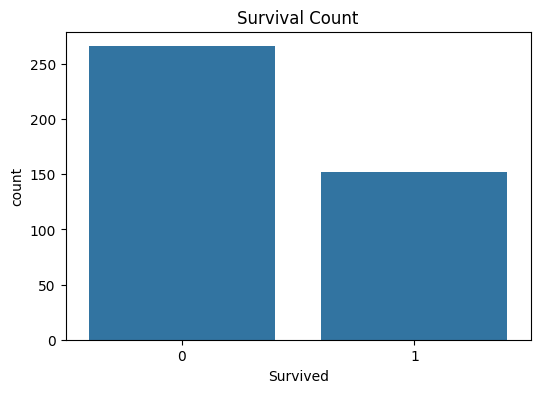

In [7]:
# ==========================================
# 8. SURVIVAL COUNT
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

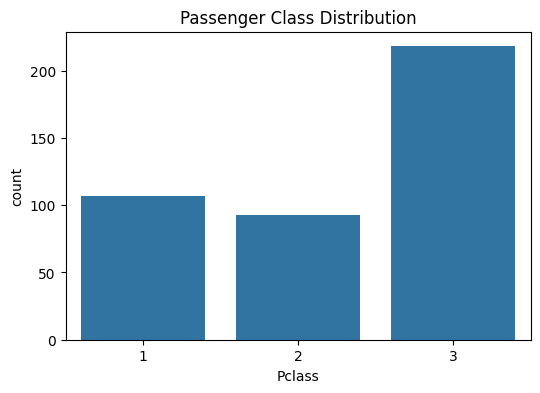

In [8]:
# ==========================================
# 9. PASSENGER CLASS DISTRIBUTION
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", data=df)
plt.title("Passenger Class Distribution")
plt.show()

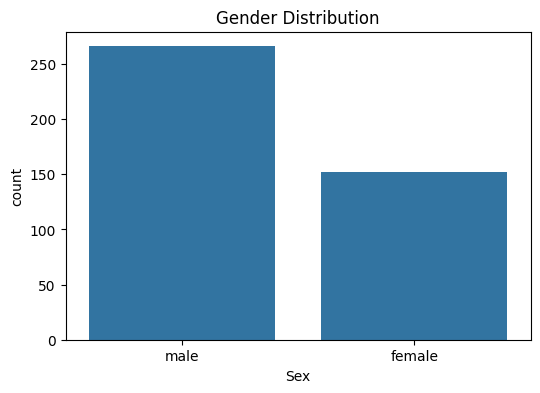

In [9]:
# ==========================================
# 10. GENDER DISTRIBUTION
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(x="Sex", data=df)
plt.title("Gender Distribution")
plt.show()

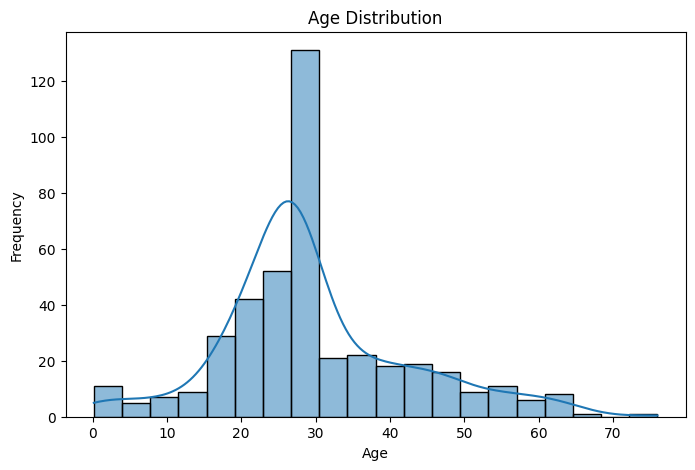

In [10]:
# ==========================================
# 11. AGE DISTRIBUTION
# ==========================================

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

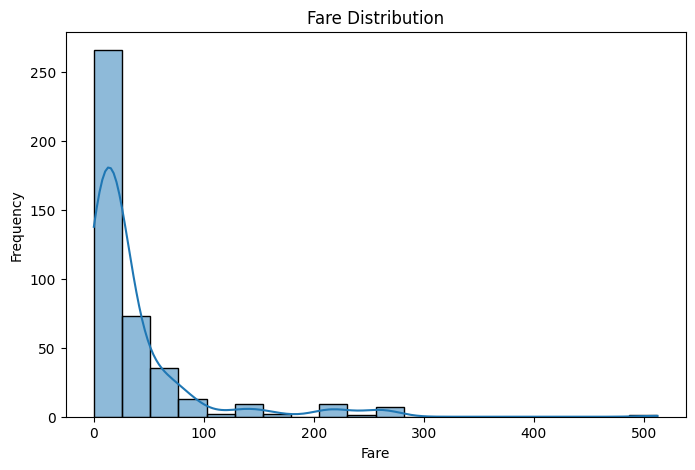

In [11]:
# ==========================================
# 12. FARE DISTRIBUTION
# ==========================================

plt.figure(figsize=(8,5))
sns.histplot(df["Fare"], bins=20, kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

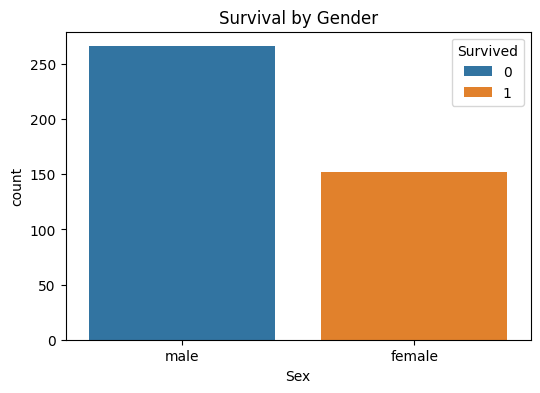

In [12]:
# ==========================================
# 13. SURVIVAL BY GENDER
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

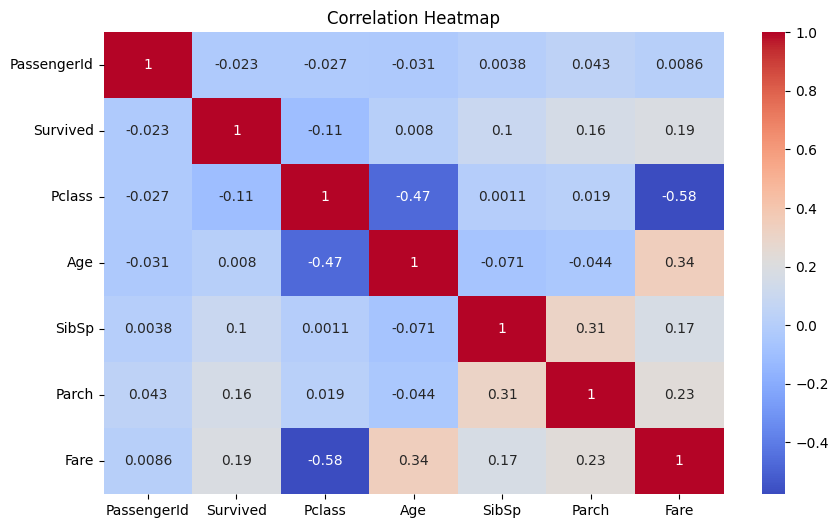

In [13]:
# ==========================================
# 14. CORRELATION HEATMAP
# ==========================================

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [14]:
# ==========================================
# 15. FINAL DATASET PREVIEW
# ==========================================

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
